<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import warnings

warnings.filterwarnings("ignore")

In [17]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn

torch.__version__

'2.10.0+cpu'

## Movie Recommendor

In [18]:
import kagglehub

path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Path to dataset files: /kaggle/input/tmdb-movie-metadata


In [19]:
df = pd.read_csv("/kaggle/input/tmdb-movie-metadata/tmdb_5000_movies.csv")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [20]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [22]:
df.isna().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [23]:
df['overview']

,overview
0,"In the 22nd century, a paraplegic Marine is di..."
1,"Captain Barbossa, long believed to be dead, ha..."
2,A cryptic message from Bond’s past sends him o...
3,Following the death of District Attorney Harve...
4,"John Carter is a war-weary, former military ca..."
...,...
4798,El Mariachi just wants to play his guitar and ...
4799,A newlywed couple's honeymoon is upended by th...
4800,"""Signed, Sealed, Delivered"" introduces a dedic..."
4801,When ambitious New York attorney Sam is sent t...


In [24]:
df.dropna(how='any', inplace=True)

In [25]:
df.isna().sum()

,0
budget,0
genres,0
homepage,0
id,0
keywords,0
original_language,0
original_title,0
overview,0
popularity,0
production_companies,0


In [26]:
features = pd.DataFrame(df, columns=['title','overview'])
features.head()

,title,overview
0,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...
4,John Carter,"John Carter is a war-weary, former military ca..."


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
corpus_vectorized = vectorizer.fit_transform(features['overview'])

In [28]:
vectorizer.get_feature_names_out()

array(['00', '000', '007', ..., 'zorro', 'zuckerberg', 'émigré'],
      dtype=object)

In [30]:
corpus_vectorized.shape

(1493, 11160)

In [31]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(corpus_vectorized, corpus_vectorized)

In [32]:
cos_sim

array([[1.        , 0.        , 0.        , ..., 0.        , 0.04311673,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.01610737, 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.01610737, 0.        , ..., 1.        , 0.        ,
        0.02188992],
       [0.04311673, 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.02188992, 0.        ,
        1.        ]])

In [33]:
indices = pd.Series(features.index, index=features['title']).drop_duplicates()

In [34]:
indices

,0
title,
Avatar,0
Pirates of the Caribbean: At World's End,1
Spectre,2
The Dark Knight Rises,3
John Carter,4
...,...
Clerks,4773
Dry Spell,4781
Tin Can Man,4791


In [38]:
indices['Avatar']

np.int64(0)

In [53]:
cosine_similarities = list(enumerate(cos_sim[indices['Avatar']]))
cosine_similarities[:3]

[(0, np.float64(1.0)), (1, np.float64(0.0)), (2, np.float64(0.0))]

In [55]:
sim_score_sorted = sorted(cosine_similarities, reverse=True, key=lambda x: x[1])
sim_score_sorted[:3]

[(0, np.float64(1.0)),
 (1243, np.float64(0.16898979315505613)),
 (355, np.float64(0.1335440689703021))]

In [56]:
top_10_similar = sim_score_sorted[:11]
top_10_similar

[(0, np.float64(1.0)),
 (1243, np.float64(0.16898979315505613)),
 (355, np.float64(0.1335440689703021)),
 (709, np.float64(0.10577312935374153)),
 (447, np.float64(0.08755321354965082)),
 (579, np.float64(0.07879773718743811)),
 (1091, np.float64(0.07592122103170823)),
 (118, np.float64(0.07409565016039914)),
 (622, np.float64(0.07309720097306685)),
 (30, np.float64(0.07307909712897004)),
 (196, np.float64(0.07155430891875453))]

In [71]:
movie_indices = [x[0] for x in top_10_similar]
movie_indices

[0, 1243, 355, 709, 447, 579, 1091, 118, 622, 30, 196]

In [72]:
features['title'].iloc[movie_indices]

,title
0,Avatar
3604,Apollo 18
634,The Matrix
1610,Hanna
847,Semi-Pro
1213,Aliens vs Predator: Requiem
2967,E.T. the Extra-Terrestrial
151,Beowulf
1345,Dolphin Tale 2
36,Transformers: Age of Extinction


## ARIMA

## CNN

In [74]:
path = kagglehub.dataset_download("anthonytherrien/dog-vs-cat")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-vs-cat' dataset.
Path to dataset files: /kaggle/input/dog-vs-cat


In [76]:
import os
from pathlib import Path

In [77]:
data_path = Path("/kaggle/input/dog-vs-cat/animals")
data_path

PosixPath('/kaggle/input/dog-vs-cat/animals')

In [87]:
all_images = list((iter(data_path.glob('*/*.png'))))
len(all_images), all_images[:3]

(1000,
 [PosixPath('/kaggle/input/dog-vs-cat/animals/dog/00985-127787239.png'),
  PosixPath('/kaggle/input/dog-vs-cat/animals/dog/00667-3846168829.png'),
  PosixPath('/kaggle/input/dog-vs-cat/animals/dog/00891-3846169053.png')])

In [96]:
import random
from PIL import Image

random_paths = random.choices(all_images, k=3)
random_paths

[PosixPath('/kaggle/input/dog-vs-cat/animals/cat/00170-200124480.png'),
 PosixPath('/kaggle/input/dog-vs-cat/animals/cat/00293-200124603.png'),
 PosixPath('/kaggle/input/dog-vs-cat/animals/dog/00981-127787235.png')]

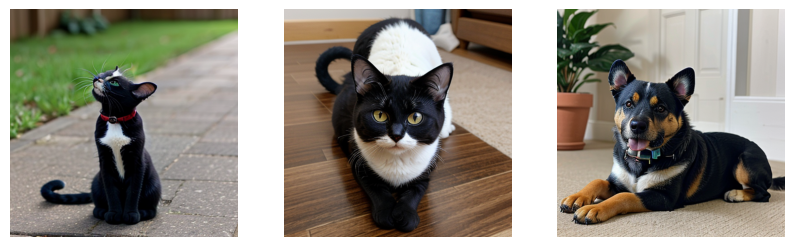

In [97]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

for idx, path in enumerate(random_paths):
  img = Image.open(path)
  ax[idx].imshow(img)
  ax[idx].axis("off")


In [98]:
import torchvision